In [ ]:
#Employee Attrition Analyzer
# M.hassan
#Roll No: 24F-Ai-66

In [ ]:
#  Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#basic checks
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nAttrition counts:\n", df["Attrition"].value_counts())


Missing values: 0
Duplicate rows: 0

Attrition counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64


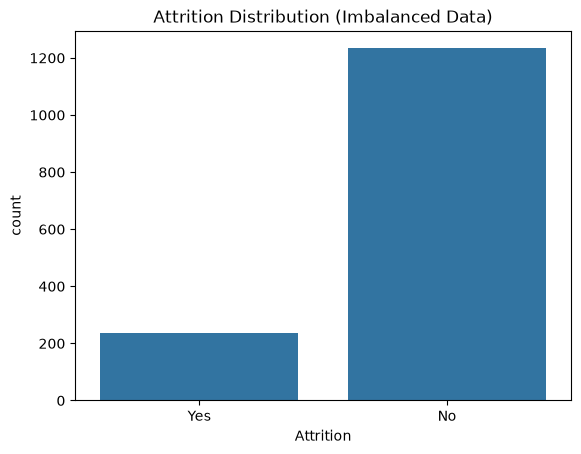

In [ ]:
# Class distribution
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution (Imbalanced Data)")
plt.show()

In [ ]:
# Preprocessing steps:
#1. Drop useless columns
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])

#2. Encode target column
y = df["Attrition"].map({"Yes": 1, "No": 0})

#3. One-Hot Encoding for categorical columns
X = pd.get_dummies(df.drop("Attrition", axis=1), drop_first=True, dtype=int)
print("Features after encoding:", X.shape[1])

#4. Train-Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Features after encoding: 44
Train: (1176, 44)  Test: (294, 44)


In [ ]:
#Model Training
# class_weight="balanced" is used because only ~16% employees left,
# so models should not ignore the minority class.

#Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

#Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

#Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=10,
                                  class_weight="balanced_subsample", random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("All 3 models trained.")

All 3 models trained.


In [ ]:
#Metrics for each model
predictions = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
}

rows = []
for name, pred in predictions.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.752,0.345,0.617,0.443
Decision Tree,0.772,0.357,0.532,0.427
Random Forest,0.827,0.460,0.489,0.474


In [ ]:
# Classification report of each model
for name, pred in predictions.items():
    print("=" * 55)
    print(name)
    print(classification_report(y_test, pred, target_names=["Stayed", "Left"]))

Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

Decision Tree
              precision    recall  f1-score   support

      Stayed       0.90      0.82      0.86       247
        Left       0.36      0.53      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.67      0.64       294
weighted avg       0.81      0.77      0.79       294

Random Forest
              precision    recall  f1-score   support

      Stayed       0.90      0.89      0.90       247
        Left       0.46      0.49      0.47        47

    accuracy                           0.83       294
   macro avg       0.68      0.69      0.69       294
weighted avg       0.83   

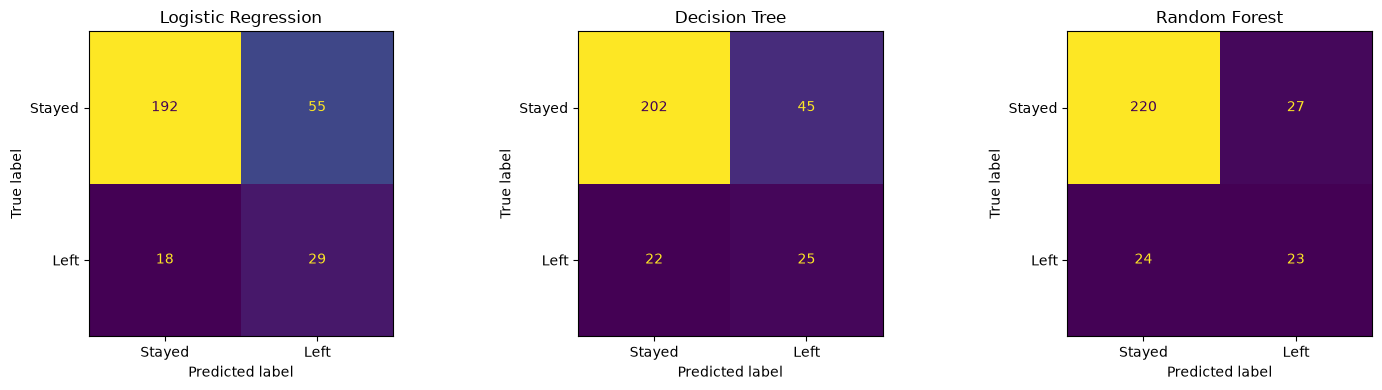

In [ ]:
#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["Stayed", "Left"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

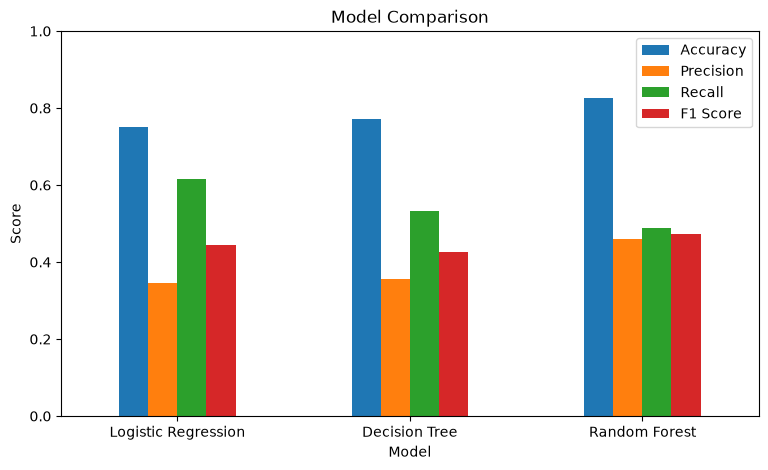

In [ ]:
#Model comparison chart
results.plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

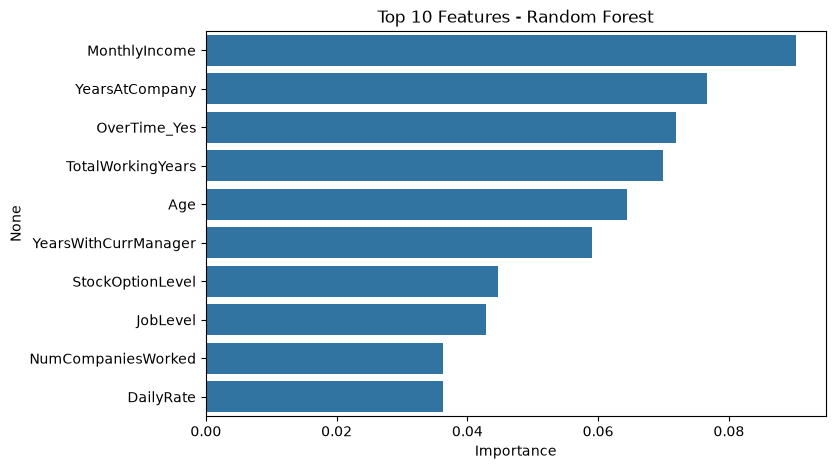

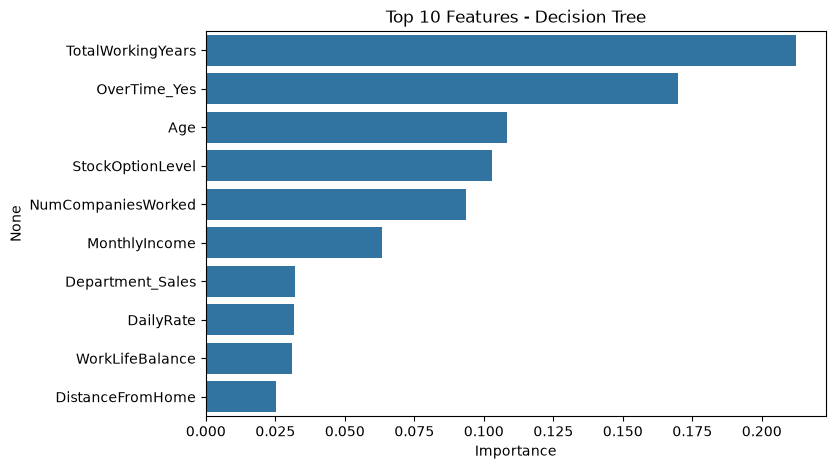

In [ ]:
#important features (Random Forest)
rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_imp.values, y=rf_imp.index)
plt.title("Top 10 Features - Random Forest")
plt.xlabel("Importance")
plt.show()

#important features (Decision Tree)
dt_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=dt_imp.values, y=dt_imp.index)
plt.title("Top 10 Features - Decision Tree")
plt.xlabel("Importance")
plt.show()